In [15]:
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from IPython.display import display, Audio,YouTubeVideo
import pyroomacoustics as pra

room=pra.room.ShoeBox(
    p= [9, 7.5, 3.5], # 2次元[幅、奥行き], ３次元[幅、奥行き、高さ]
    fs=8000, # サンプリング周波数
    t0=0.0, # シミュレーションの開始時間
    absorption=None,  # 平均壁面吸音率（materialsを設定するときは不要）
    max_order=1, # 鏡像法における反射回数の上限 *1
    sigma2_awgn=None, # ガウシアンノイズを乗せる
    sources=None, # 音源データ(リスト)。マイク設定と一緒に使う
    mics=None,  # マイク座標のリスト（リスト）。音源設定と一緒に使う。
    materials=None, # 建材の設定。詳しくはこの後に書きます。
    temperature=None, # 室温(摂氏)。音速に影響。特に書かないと343m/s
    humidity=None, # 湿度(%)。音速に影響。
    air_absorption=False, # 空気吸収。*2
    ray_tracing=False, # レイトレーシングと鏡像法のハイブリッド利用
    use_rand_ism=False, # よくわからん。音像位置がランダムになる？
    max_rand_disp=0.0 # 上のと一緒に使う
)

In [7]:
# 残響時間と部屋の寸法
rt60 = 0.5  # seconds
room_dim = [9, 7.5, 3.5]  # meters ここを二次元にすると二次平面の部屋になります

# Sabineの残響式から壁面の平均吸音率と鏡像法での反射回数の上限を決めます
e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)

# 部屋をつくります
# fsは生成されるインパルス応答のサンプリング周波数です。入力する音源があるならそれに合わせる。
room = pra.ShoeBox(
    room_dim, fs=16000, materials=pra.Material(e_absorption), max_order=max_order
)
import pyroomacoustics as pra
m = pra.make_materials(
    ceiling=(0.1, 0.05),  # (흡음, 산란)
    floor=(0.2, 0.1),
    east=(0.1, 0.05),
    west=(0.1, 0.05),
    north=(0.1, 0.05),
    south=(0.1, 0.05)
)
room = pra.ShoeBox(
    [9, 7.5, 3.5], fs=16000, materials=m, max_order=17)

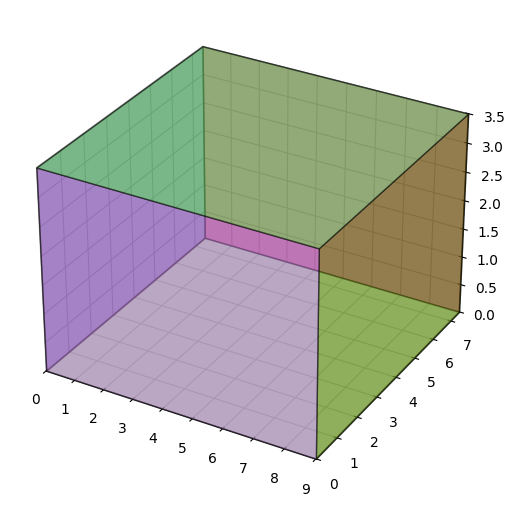

In [60]:
fig, ax = room.plot()

In [ ]:

mic_locs = np.c_[
    [6.3, 4.87, 1.2], [6.3, 4.93, 1.2],  # mic 1  # mic 2
]
vid=YouTubeVideo('v=pcSvhVTBCRk')

# room にマイクを追加します
room.add_microphone_array(mic_locs)
_, audio1 = wavfile.read('speech1.wav')
audio1=audio1/ 32768.0
_, audio2 = wavfile.read('speech2.wav')
audio2=audio2/ 32768.0
_, audio3 = wavfile.read('speech3.wav')
audio3=audio3/ 32768.0
# 音源ごとに座標情報を与え、`room`に追加していきます。
# オプションで delay を追加することもできます。
room.add_source([2.5, 2.1, 1.76], signal=audio1, delay=1.3)
room.add_source([1.0, 2.34, 1], signal=audio2)
room.add_source([3.2, 1.7, 1], signal=audio3, delay=2.)
fig, ax = room.plot()
ax.set_xlim([0, 9]) # 방 크기에 맞춰 조절
ax.set_ylim([0, 7.5])
ax.set_zlim([0, 3.5])
plt.show()

TypeError: cannot unpack non-iterable YouTubeVideo object

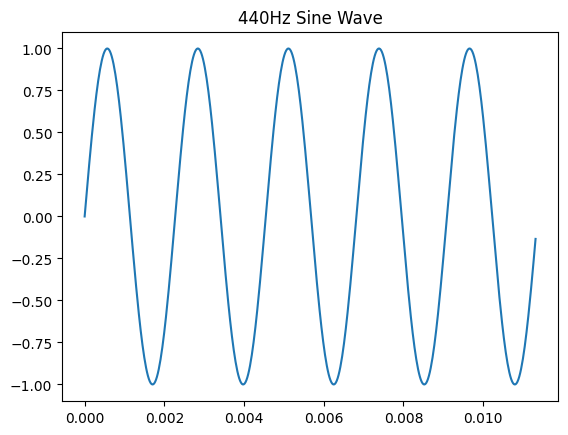

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 환경 설정
fs = 44100        # 샘플링 레이트 (1초를 44,100개로 쪼갬)
duration = 1.0    # 1초 동안 재생
f = 440           # 주파수 440Hz

# 2. 시간축 생성 (0초부터 1초까지 fs개만큼 생성)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# 3. 사인파 생성 (math.sin 대신 np.sin 사용)
# np.sin을 쓰면 t 배열 전체를 한 번에 계산하므로 훨씬 빠릅니다.
signal = np.sin(2 * np.pi * f * t)

# 확인을 위해 아주 짧은 구간(0.01초)만 그려보기
plt.plot(t[:500], signal[:500])
plt.title("440Hz Sine Wave")
plt.show()

In [42]:
import numpy as np
mic_locs=[]
micarray_ichi=np.linspace(4,5,10,endpoint=False)
print('마이크 어레이의 y위치\n',micarray_ichi,type(micarray_ichi))
for i in micarray_ichi:
    mic_locs.append([6.3,i,1.2])
mic_locs=np.array(mic_locs).T
print('마이크 어레이의 최종 위치\n',mic_locs,type(mic_locs))


마이크 어레이의 y위치
 [4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9] <class 'numpy.ndarray'>
마이크 어레이의 최종 위치
 [[6.3 6.3 6.3 6.3 6.3 6.3 6.3 6.3 6.3 6.3]
 [4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9]
 [1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2]] <class 'numpy.ndarray'>


In [8]:
import numpy as np
mic_locs = np.c_[
    [6.3, 4.87, 1.2], [6.3, 4.93, 1.2],  # mic 1  # mic 2
]
print(mic_locs)


[[6.3  6.3 ]
 [4.87 4.93]
 [1.2  1.2 ]]


In [44]:
pip install PyQt5

   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.9 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.9 MB 1.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.0/6.9 MB 2.1 MB/s eta 0:00:03
   ------- -------------------------------- 1.3/6.9 MB 2.0 MB/s eta 0:00:03
   ------------ --------------------------- 2.1/6.9 MB 2.4 MB/s eta 0:00:02
   ---------------- ----------------------- 2.9/6.9 MB 2.6 MB/s eta 0:00:02
   --------------------- ------------------ 3.7/6.9 MB 2.8 MB/s eta 0:00:02
   ------------------------- -------------- 4.5/6.9 MB 2.9 MB/s eta 0:00:01
   -------------------------------- ------- 5.5/6.9 MB 3.2 MB/s eta 0:00:01
   ----------------------------------- ---- 6.0/6.9 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 6.9/6.9 MB 3.2 MB/s  0:00:02
   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   --------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [12]:
room.simulate()
simulation_data = room.mic_array.signals # シミュレーション音源
vid=YouTubeVideo('v=pcSvhVTBCRk')
display(vid)
room.compute_rir()
display(Audio(room.rir[0][0], rate=room.fs))
rt60 = room.measure_rt60()
print("残響時間：{}".format(rt60))

ValueError: There are no sound sources in the room.